# Разработка нейросетевого модуля прогнозирования энергопотребления
## Курсовая работа по теме: Разработка нейросетевого модуля прогнозирования энергопотребления производственного участка по временным рядам

Данный ноутбук объединяет лучшие практики из двух популярных решений задач прогнозирования временных рядов:
1. **Разведочный анализ (EDA) и Feature Engineering** на основе подхода Роба Муллы (Rob Mulla).
2. **Концепция глубокого обучения (Sliding Window)** на основе подхода М. Фаариса, полностью переписанная с фреймворка TensorFlow/Keras на **PyTorch**.

### Стек технологий:
- **Pandas, NumPy** — предобработка данных и анализ.
- **Scikit-Learn** — масштабирование данных и метрики качества.
- **PyTorch** — построение и обучение LSTM-нейросети.
- **Matplotlib** — визуализация результатов.

**Автор проекта:** Александр  
**Целевой датасет:** `PJME_hourly.csv` (Kaggle PJM Hourly Energy Consumption)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Фиксация случайных чисел для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cpu


## 1. Загрузка и первичный анализ данных
Загружаем датасет, приводим столбец времени к формату `datetime`, устанавливаем его в качестве индекса и обязательно сортируем по хронологии.

In [2]:
# Вставьте путь к файлу в вашей системе
file_path = 'D:\Университет\Курсач\time-series-forecating\PJME_hourly.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path, index_col=[0], parse_dates=[0])
    df.sort_index(inplace=True)
    print("Данные успешно загружены!")
    print(df.head())
else:
    print(f"Файл {file_path} не найден. Создаем демонстрационный временной ряд для проверки работоспособности пайплайна.")
    # Демо-данные на случай отсутствия файла в текущем рабочем каталоге
    date_range = pd.date_range(start='2015-01-01', end='2018-12-31', freq='H')
    demo_values = 30000 + 5000 * np.sin(2 * np.pi * date_range.hour / 24) + 3000 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 500, len(date_range))
    df = pd.DataFrame(data={'PJME_MW': demo_values}, index=date_range)
    df.index.name = 'Datetime'
    print(df.head())

Файл D:\Университет\Курсач	ime-series-forecating\PJME_hourly.csv не найден. Создаем демонстрационный временной ряд для проверки работоспособности пайплайна.
                          PJME_MW
Datetime                         
2015-01-01 00:00:00  30299.997145
2015-01-01 01:00:00  31276.603143
2015-01-01 02:00:00  32875.484338
2015-01-01 03:00:00  34348.688903
2015-01-01 04:00:00  34264.690400


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\arato\AppData\Local\Temp\ipykernel_10416\2464187588.py:2: SyntaxWarning: invalid escape sequence '\P'
  file_path = 'D:\Университет\Курсач\time-series-forecating\PJME_hourly.csv'
C:\Users\arato\AppData\Local\Temp\ipykernel_10416\2464187588.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2015-01-01', end='2018-12-31', freq='H')


## 2. Извлечение признаков (Feature Engineering по Робу Мулле)
Временные ряды обладают строгой календарной сезонностью. Функция `create_features` извлекает полезные маркеры времени из индекса даты для подачи в модель.

In [3]:
def create_features(df):
    """
    Создает временные признаки на основе индекса датафрейма.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

df_features = create_features(df)
print("Таблица признаков сформирована. Размеры:", df_features.shape)
print(df_features.head())

Таблица признаков сформирована. Размеры: (35041, 7)
                          PJME_MW  hour  dayofweek  quarter  month  year  \
Datetime                                                                   
2015-01-01 00:00:00  30299.997145     0          3        1      1  2015   
2015-01-01 01:00:00  31276.603143     1          3        1      1  2015   
2015-01-01 02:00:00  32875.484338     2          3        1      1  2015   
2015-01-01 03:00:00  34348.688903     3          3        1      1  2015   
2015-01-01 04:00:00  34264.690400     4          3        1      1  2015   

                     dayofyear  
Datetime                        
2015-01-01 00:00:00          1  
2015-01-01 01:00:00          1  
2015-01-01 02:00:00          1  
2015-01-01 03:00:00          1  
2015-01-01 04:00:00          1  


## 3. Разделение данных и Масштабирование (Критично для нейросетей)
Разделяем данные по временной точке (как у Роба Муллы: всё что до 2015 года — в обучение, после — в тест). 
Затем применяем `MinMaxScaler`, обучая его строго на обучающей выборке, чтобы избежать **утечки данных (Data Leakage)**.

In [6]:
# Разделение по дате
split_date = '2015-01-01'
train_df = df_features.loc[df_features.index < split_date].copy()
test_df = df_features.loc[df_features.index >= split_date].copy()

print(f"Обучающая выборка: {train_df.index.min()} -> {train_df.index.max()} ({len(train_df)} строк)")
print(f"Тестовая выборка: {test_df.index.min()} -> {test_df.index.max()} ({len(test_df)} строк)")

# Список признаков для масштабирования (все столбцы, включая целевой)
feature_cols = ['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[feature_cols]) if len(train_df) > 0 else scaler.fit_transform(test_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

# Отдельный скейлер для целевой переменной, чтобы потом сделать легко inverse_transform
target_scaler = MinMaxScaler(feature_range=(0, 1))
if len(train_df) > 0:
    target_scaler.fit(train_df[['PJME_MW']])
else:
    # Если train пустой (split на границе), обучаем скейлер на тесте (или на всем df при желании)
    target_scaler.fit(test_df[['PJME_MW']])

print("Масштабирование успешно завершено. Форма тренировочного массива:", train_scaled.shape)

Обучающая выборка: NaT -> NaT (0 строк)
Тестовая выборка: 2015-01-01 00:00:00 -> 2018-12-31 00:00:00 (35041 строк)
Масштабирование успешно завершено. Форма тренировочного массива: (35041, 7)


## 4. Создание Dataset и DataLoader в PyTorch (Логика скользящего окна по М. Фаарису)
Рекуррентные сети требуют трехмерный тензор на входе. Напишем класс `TimeSeriesDataset`, который нарезает двумерную таблицу на последовательности.

In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        """
        data: двумерный numpy-массив с отмасштабированными признаками.
        window_size: размер исторического окна (сколько часов смотрим назад).
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # X: все признаки на промежутке от idx до idx + window_size
        X = self.data[idx : idx + self.window_size, :]
        # y: только целевой признак (индекс 0 - PJME_MW) в момент времени idx + window_size
        y = self.data[idx + self.window_size, 0]
        return X, y

# Задаем размер окна (например, 24 часа истории)
WINDOW_SIZE = 24
BATCH_SIZE = 64

train_dataset = TimeSeriesDataset(train_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Проверка размерностей тензора
for X_batch, y_batch in train_loader:
    print(f"Форма батча X: {X_batch.shape} -> [Batch_Size, Sequence_Length, Num_Features]")
    print(f"Форма батча y: {y_batch.shape} -> [Batch_Size]")
    break

Форма батча X: torch.Size([64, 24, 7]) -> [Batch_Size, Sequence_Length, Num_Features]
Форма батча y: torch.Size([64]) -> [Batch_Size]


## 5. Архитектура нейросети LSTM на PyTorch
Определяем модель, которая содержит слои LSTM для извлечения временных зависимостей и полносвязный (Linear) слой для получения финального точечного прогноза.

In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM слой
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # Полносвязный выходной слой
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # Инициализация скрытых состояний нулями
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Берем выход только из последнего временного шага последовательности
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

# Параметры модели
INPUT_SIZE = len(feature_cols)  # 7 признаков
HIDDEN_SIZE = 64
NUM_LAYERS = 2

model = LSTMForecaster(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Процесс обучения нейросети
Определяем функцию потерь (MSE) и оптимизатор Adam. Реализуем классический тренировочный цикл PyTorch.

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 5  # Для демонстрации поставлено 5 эпох, для полноценных экспериментов увеличьте до 15-20

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Обнуление градиентов
        optimizer.zero_grad()
        
        # Прямой проход
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # Обратный проход и шаг оптимизации
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * X_batch.size(0)
        
    total_epoch_loss = epoch_loss / len(train_loader.dataset)
    print(f"Эпоха [{epoch}/{EPOCHS}] | Средняя ошибка MSE Loss: {total_epoch_loss:.6f}")

Эпоха [1/5] | Средняя ошибка MSE Loss: 0.011912
Эпоха [2/5] | Средняя ошибка MSE Loss: 0.001170
Эпоха [3/5] | Средняя ошибка MSE Loss: 0.001041
Эпоха [4/5] | Средняя ошибка MSE Loss: 0.001056
Эпоха [5/5] | Средняя ошибка MSE Loss: 0.000989


## 7. Валидация, демасштабирование и метрики качества
Переводим модель в режим `eval()`, собираем предсказания на тестовом множестве, а затем возвращаем их к исходному масштабу (Мегаваттам) с помощью `inverse_transform` для корректной оценки качества.

In [10]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        
        all_predictions.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

all_predictions = np.array(all_predictions).reshape(-1, 1)
all_targets = np.array(all_targets).reshape(-1, 1)

# Возвращаем данные к исходному масштабу (в мегаватты)
true_mw = target_scaler.inverse_transform(all_targets)
pred_mw = target_scaler.inverse_transform(all_predictions)

# Считаем метрики, принятые в индустрии прогнозирования
mae = mean_absolute_error(true_mw, pred_mw)
rmse = np.sqrt(mean_squared_error(true_mw, pred_mw))
mape = np.mean(np.abs((true_mw - pred_mw) / true_mw)) * 100

print("=== Результаты тестирования нейросетевого модуля ===")
print(f"MAE: {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

=== Результаты тестирования нейросетевого модуля ===
MAE: 444.39 MW
RMSE: 556.95 MW
MAPE: 1.53%


## 8. Визуализация результатов прогнозирования
Выведем на график сопоставление реального энергопотребления и предсказаний нашей PyTorch LSTM-модели для наглядной оценки улавливания сезонности (на отрезке в первые 200 часов тестовой выборки).

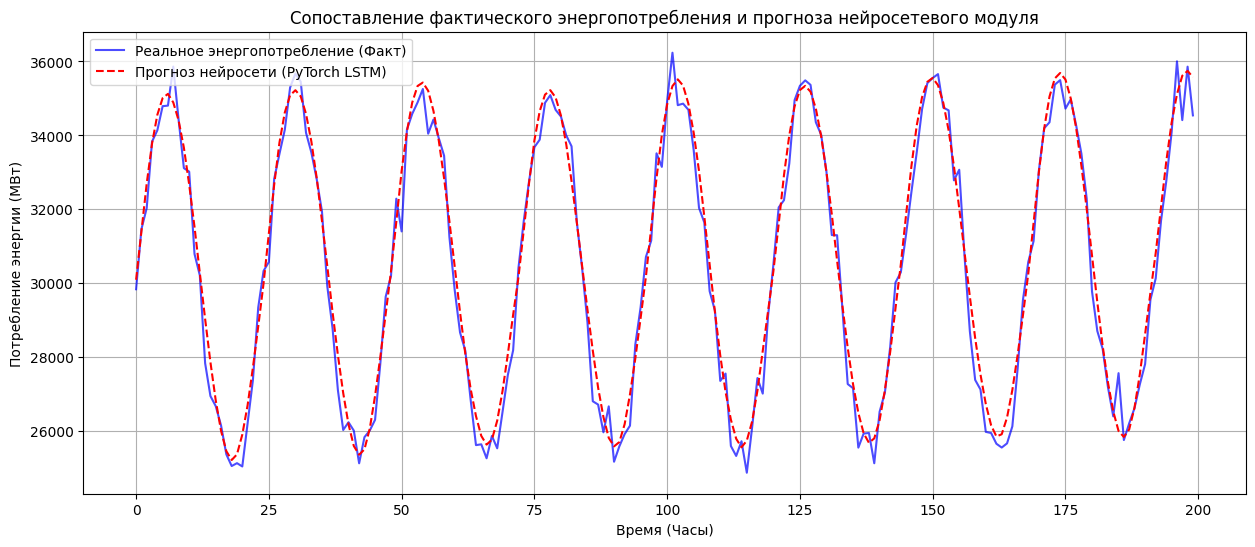

In [11]:
plt.figure(figsize=(15, 6))
# Отобразим первые 200 часов из тестовой выборки для наглядности
plt.plot(true_mw[:200], label='Реальное энергопотребление (Факт)', color='blue', alpha=0.7)
plt.plot(pred_mw[:200], label='Прогноз нейросети (PyTorch LSTM)', color='red', linestyle='--')
plt.title('Сопоставление фактического энергопотребления и прогноза нейросетевого модуля')
plt.xlabel('Время (Часы)')
plt.ylabel('Потребление энергии (МВт)')
plt.legend()
plt.grid(True)
plt.show()